<a href="https://colab.research.google.com/github/shahyan01/mvc-mlp-i250143/blob/main/src/mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/20 Loss: 0.0296
Epoch 2/20 Loss: 0.0208
Epoch 3/20 Loss: 0.0172
Epoch 4/20 Loss: 0.0153
Epoch 5/20 Loss: 0.0138
Epoch 6/20 Loss: 0.0127
Epoch 7/20 Loss: 0.0119
Epoch 8/20 Loss: 0.0111
Epoch 9/20 Loss: 0.0105
Epoch 10/20 Loss: 0.0100
Epoch 11/20 Loss: 0.0095
Epoch 12/20 Loss: 0.0091
Epoch 13/20 Loss: 0.0088
Epoch 14/20 Loss: 0.0084
Epoch 15/20 Loss: 0.0081
Epoch 16/20 Loss: 0.0078
Epoch 17/20 Loss: 0.0076
Epoch 18/20 Loss: 0.0073
Epoch 19/20 Loss: 0.0071
Epoch 20/20 Loss: 0.0069


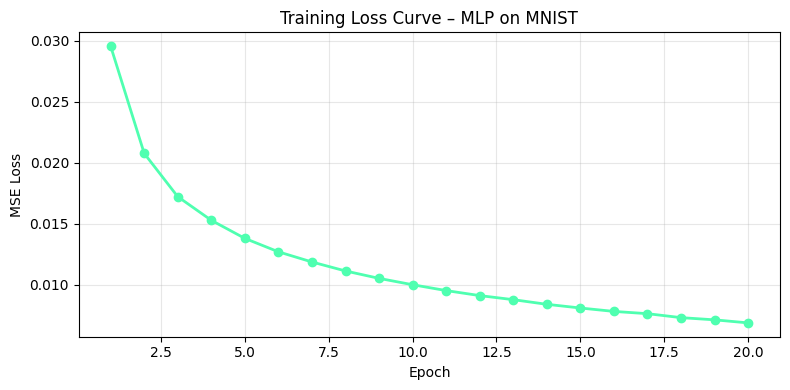

Test Accuracy: 95.54%


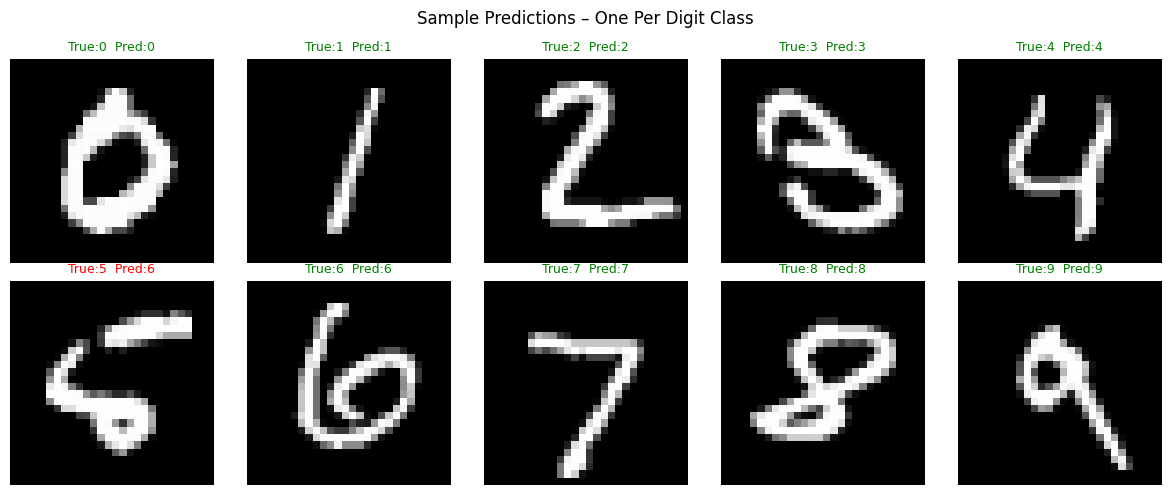

In [23]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

data = np.load('../data/mnist.npz')
X_train = data['x_train'].reshape(-1, 784) / 255.0 # (60000, 784)
Y_train = data['y_train'] # (60000,)
X_test = data['x_test'].reshape(-1, 784) / 255.0 # (10000, 784)
Y_test = data['y_test'] # (10000,)

def one_hot(y, num_classes=10):
    oh = np.zeros((y.shape[0], num_classes))
    oh[np.arange(y.shape[0]), y] = 1
    return oh

Y_train_oh = one_hot(Y_train)
Y_test_oh  = one_hot(Y_test)

W1 = np.random.uniform(-0.5, 0.5, (784, 128))
b1 = np.zeros((1, 128))
W2 = np.random.uniform(-0.5, 0.5, (128, 64))
b2 = np.zeros((1, 64))
W3 = np.random.uniform(-0.5, 0.5, (64, 10))
b3 = np.zeros((1, 10))

#Step 1 - Sigmoid Activation Function
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

#Step 2 - Forward Pass
def forward_pass(X, W1, b1, W2, b2, W3, b3):
    # Layer 1
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)
    # Layer 2
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    # Output layer
    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)
    return Z1, A1, Z2, A2, Z3, A3

#Step 3 - MSE Loss
def mse_loss(Y_true, Y_pred):
    return np.mean((Y_true - Y_pred) ** 2)

#Step 4 - Backpropagation
def backpropagation(X, Y_true, Z1, A1, Z2, A2, Z3, A3,
W1, W2, W3):
    m = X.shape[0]
    # Output layer delta
    delta3 = -2*(Y_true - A3) * sigmoid_derivative(A3)
    # Gradients for W3, b3
    dW3 = (A2.T @ delta3) / m
    db3 = np.sum(delta3, axis=0, keepdims=True) / m
    # Hidden layer 2 delta
    delta2 = delta3 @ W3.T * sigmoid_derivative(A2)
    # Gradients for W2, b2
    dW2 = (A1.T @ delta2) / m
    db2 = np.sum(delta2, axis=0, keepdims=True) / m
    # Hidden layer 1 delta
    delta1 = delta2 @ W2.T * sigmoid_derivative(A1)
    # Gradients for W1, b1
    dW1 = (X.T @ delta1) / m
    db1 = np.sum(delta1, axis=0, keepdims=True) / m
    return dW1, db1, dW2, db2, dW3, db3

#Step 5 - Weight Update
def update_weights(W1, b1, W2, b2, W3, b3,
                    dW1, db1, dW2, db2, dW3, db3,
                    learning_rate):
    # Apply: W = W - learning_rate * dW
    # b = b - learning_rate * db
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3
    # Return all updated weights and biases
    return W1, b1, W2, b2, W3, b3

#Training loop
learning_rate = 0.1
epochs = 20
batch_size = 32
loss_history = []

for epoch in range(epochs):
    # Shuffle training data
    idx = np.random.permutation(X_train.shape[0])
    X_shuf = X_train[idx]
    Y_shuf = Y_train_oh[idx] # one-hot labels

    # Mini-batch loop
    for start in range(0, X_train.shape[0], batch_size):
        X_batch = X_shuf[start : start + batch_size]
        Y_batch = Y_shuf[start : start + batch_size]

        # Step 1: Forward pass
        Z1,A1,Z2,A2,Z3,A3 = forward_pass(X_batch, W1,b1,W2,b2,W3,b3)

        # Step 2: Compute loss
        loss = mse_loss(Y_batch, A3)

        # Step 3: Backpropagation
        dW1,db1,dW2,db2,dW3,db3 = backpropagation(
            X_batch, Y_batch, Z1,A1,Z2,A2,Z3,A3, W1,W2,W3)

        # Step 4: Update weights
        W1,b1,W2,b2,W3,b3 = update_weights(
            W1,b1,W2,b2,W3,b3,
            dW1,db1,dW2,db2,dW3,db3, learning_rate)

    # Record epoch loss
    _,_,_,_,_,A3_full = forward_pass(X_train,W1,b1,W2,b2,W3,b3)
    epoch_loss = mse_loss(Y_train_oh, A3_full)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs} Loss: {epoch_loss:.4f}")

#Output 1: Loss Curve
plt.figure(figsize=(8,4))
plt.plot(range(1, epochs+1), loss_history, 'o-', color='#4fffb0', lw=2)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training Loss Curve – MLP on MNIST')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

#Output 2: Test Accuracy
_,_,_,_,_,A3_test = forward_pass(X_test, W1,b1,W2,b2,W3,b3)
Y_pred_test = np.argmax(A3_test, axis=1)
accuracy = np.mean(Y_pred_test == Y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

#Output 3: Sample Predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    idx  = np.where(Y_test == digit)[0][0]
    img  = X_test[idx].reshape(28, 28)
    pred = preds[idx]
    ax   = axes[digit // 5][digit % 5]
    ax.imshow(img, cmap='gray')
    color = 'green' if pred == digit else 'red'
    ax.set_title(f"True:{digit}  Pred:{pred}", color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Predictions – One Per Digit Class')
plt.tight_layout(); plt.show()
